In [55]:
import pandas as pd          # Data manipulation (like Excel on steroids)
import numpy as np           # Math operations
import matplotlib.pyplot as plt   # Basic charts
import seaborn as sns        # Prettier charts
import warnings
warnings.filterwarnings('ignore')  # Hide unnecessary warning messages
 
# Set visual style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150  # Higher quality charts
plt.rcParams['font.size'] = 11
 
print(" All libraries loaded successfully!")
 

 All libraries loaded successfully!


In [56]:
df = pd.read_excel('Python3/Online Retail.xlsx')
 
print(f"   Dataset loaded!")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")
print(f"   Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"\n--- First 5 rows ---")
df.head()

   Dataset loaded!
   Rows: 541,909
   Columns: 8
   Date range: 2010-12-01 to 2011-12-09

--- First 5 rows ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [57]:
print("=" * 60)
print("DATA HEALTH CHECK")
print("=" * 60)
 
print("\n Column types:")
print(df.dtypes)
 
print(f"\n Missing values:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
for col in df.columns:
    if missing[col] > 0:
        print(f"   {col}: {missing[col]:,} ({missing_pct[col]}%)")
 
print(f"\n Basic statistics:")
print(df.describe().round(2))
 
print(f"\n Top 5 countries by transactions:")
print(df['Country'].value_counts().head())

DATA HEALTH CHECK

📋 Column types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

 Missing values:
   Description: 1,454 (0.3%)
   CustomerID: 135,080 (24.9%)

 Basic statistics:
        Quantity                    InvoiceDate  UnitPrice  CustomerID
count  541909.00                         541909  541909.00   406829.00
mean        9.55  2011-07-04 13:34:57.156386048       4.61    15287.69
min    -80995.00            2010-12-01 08:26:00  -11062.06    12346.00
25%         1.00            2011-03-28 11:34:00       1.25    13953.00
50%         3.00            2011-07-19 17:17:00       2.08    15152.00
75%        10.00            2011-10-19 11:27:00       4.13    16791.00
max     80995.00            2011-12-09 12:50:00   38970.00    18287.00
std       218.08                            N

In [58]:

 
print(" CLEANING THE DATA\n")
 
rows_before = len(df)
 
# STEP 1: Remove rows where CustomerID is missing
# WHY: We can't analyse a customer if we don't know WHO they are.
# These are likely guest checkouts — useless for CLV analysis.
df = df.dropna(subset=['CustomerID'])
print(f"Step 1 — Removed rows without CustomerID: {rows_before - len(df):,} rows dropped")
 
# STEP 2: Remove cancelled orders (InvoiceNo starts with 'C')
# WHY: Cancellations aren't real revenue. Including them would inflate
# some customers' frequency and deflate their monetary value.
rows_temp = len(df)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Step 2 — Removed cancellations: {rows_temp - len(df):,} rows dropped")
 
# STEP 3: Remove rows where Quantity or Price is zero or negative
# WHY: A purchase of 0 items at $0 isn't a real transaction.
# Negative quantities are returns (already handled by cancellation filter).
rows_temp = len(df)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f"Step 3 — Removed zero/negative quantities & prices: {rows_temp - len(df):,} rows dropped")
 
# STEP 4: Create a 'Revenue' column
# WHY: Revenue = Quantity × Price. This is what the business ACTUALLY cares about.
# No one asks "how many units did Customer X buy?" They ask "how much did they spend?"
df['Revenue'] = df['Quantity'] * df['UnitPrice']
 
# STEP 5: Convert CustomerID to integer (it loaded as decimal: 17850.0 → 17850)
df['CustomerID'] = df['CustomerID'].astype(int)
 
print(f"\n Clean dataset: {len(df):,} rows | {df['CustomerID'].nunique():,} unique customers")
print(f"   Total revenue: £{df['Revenue'].sum():,.2f}")
 

 CLEANING THE DATA

Step 1 — Removed rows without CustomerID: 135,080 rows dropped
Step 2 — Removed cancellations: 8,905 rows dropped
Step 3 — Removed zero/negative quantities & prices: 40 rows dropped

 Clean dataset: 397,884 rows | 4,338 unique customers
   Total revenue: £8,911,407.90


In [59]:
# RFM = Recency, Frequency, Monetary

 
print(" CALCULATING RFM METRICS\n")
 
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Reference date (our 'today'): {reference_date.date()}")
 
# Group all transactions by customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  
    'InvoiceNo': 'nunique',                                     
    'Revenue': 'sum'                                            
}).reset_index()
 
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
 
print(f"\n RFM Summary:")
print(f"   Avg Recency:  {rfm['Recency'].mean():.0f} days since last purchase")
print(f"   Avg Frequency: {rfm['Frequency'].mean():.1f} orders per customer")
print(f"   Avg Monetary:  £{rfm['Monetary'].mean():.2f} total spend per customer")
 
rfm.head(10)

 CALCULATING RFM METRICS

Reference date (our 'today'): 2011-12-10

 RFM Summary:
   Avg Recency:  93 days since last purchase
   Avg Frequency: 4.3 orders per customer
   Avg Monetary:  £2054.27 total spend per customer


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [60]:
print(" SCORING CUSTOMERS (1-5 scale)\n")
 
# Recency: LOWER is BETTER (bought recently), so labels are reversed
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
 
# Frequency: HIGHER is BETTER (buys often)
# rank(method='first') handles ties — without it, qcut can fail on duplicate values
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
 
# Monetary: HIGHER is BETTER (spends more)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])
 
# Combined RFM score as a string (e.g., "555" = best customer possible)
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) +
                    rfm['F_Score'].astype(str) +
                    rfm['M_Score'].astype(str))
 
print("Score distribution:")
print(f"   R scores: {rfm['R_Score'].value_counts().sort_index().to_dict()}")
print(f"   F scores: {rfm['F_Score'].value_counts().sort_index().to_dict()}")
print(f"   M scores: {rfm['M_Score'].value_counts().sort_index().to_dict()}")
 
rfm.head(10)

 SCORING CUSTOMERS (1-5 scale)

Score distribution:
   R scores: {5: 868, 4: 904, 3: 858, 2: 843, 1: 865}
   F scores: {1: 868, 2: 867, 3: 868, 4: 867, 5: 868}
   M scores: {1: 868, 2: 867, 3: 868, 4: 867, 5: 868}


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112
5,12352,36,8,2506.04,3,5,5,355
6,12353,204,1,89.00,1,1,1,111
7,12354,232,1,1079.40,1,1,4,114
8,12355,214,1,459.40,1,1,2,112
9,12356,23,3,2811.43,4,3,5,435


In [61]:
print(" CREATING CUSTOMER SEGMENTS\n")
 
def segment_customer(row):
    """Assign a business-meaningful segment based on RFM scores."""
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
 
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'         # Recent, frequent, big spenders — PROTECT THEM
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'    # Consistent buyers — REWARD THEM
    elif r >= 4 and f <= 2:
        return 'New Customers'      # Just arrived — NURTURE THEM
    elif r >= 3 and f >= 1 and m >= 3:
        return 'Potential Loyalists' # Showing promise — ENCOURAGE THEM
    elif r <= 2 and f >= 3:
        return 'At Risk'            # Were good customers, now fading — WIN THEM BACK
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Can\'t Lose Them'   # High value but leaving — URGENT ACTION
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'               # Gone. Don't waste money here.
    else:
        return 'Needs Attention'    # Middle of the road — MONITOR
 
rfm['Segment'] = rfm.apply(segment_customer, axis=1)
 
# Display segment counts
segment_counts = rfm['Segment'].value_counts()
print("Customer segments:")
for seg, count in segment_counts.items():
    pct = count / len(rfm) * 100
    print(f"   {seg}: {count} customers ({pct:.1f}%)")
 
 

 CREATING CUSTOMER SEGMENTS

Customer segments:
   Loyal Customers: 998 customers (23.0%)
   Champions: 962 customers (22.2%)
   Lost: 824 customers (19.0%)
   At Risk: 643 customers (14.8%)
   Needs Attention: 489 customers (11.3%)
   New Customers: 319 customers (7.4%)
   Potential Loyalists: 103 customers (2.4%)


In [62]:
print("SEGMENT DEEP DIVE\n")
 
segment_summary = rfm.groupby('Segment').agg({
    'CustomerID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum']
}).round(1)
 
segment_summary.columns = ['Customers', 'Avg_Recency_Days', 'Avg_Frequency',
                           'Avg_Revenue_Per_Customer', 'Total_Revenue']
 
# Add revenue percentage — this is the KILLER insight
segment_summary['Revenue_%'] = (
    segment_summary['Total_Revenue'] / segment_summary['Total_Revenue'].sum() * 100
).round(1)
 
# Add customer percentage
segment_summary['Customer_%'] = (
    segment_summary['Customers'] / segment_summary['Customers'].sum() * 100
).round(1)
 
# Sort by total revenue (most valuable first)
segment_summary = segment_summary.sort_values('Total_Revenue', ascending=False)
 
print(segment_summary.to_string())
 
# THE KEY INSIGHT — print it clearly
top_seg = segment_summary.index[0]
top_rev_pct = segment_summary.iloc[0]['Revenue_%']
top_cust_pct = segment_summary.iloc[0]['Customer_%']
print(f"\n KEY INSIGHT: {top_seg} represent just {top_cust_pct}% of customers")
print(f"   but contribute {top_rev_pct}% of all revenue!")
 

SEGMENT DEEP DIVE

                     Customers  Avg_Recency_Days  Avg_Frequency  Avg_Revenue_Per_Customer  Total_Revenue  Revenue_%  Customer_%
Segment                                                                                                                        
Champions                  962              12.9           11.1                    6038.8      5809341.1       65.2        22.2
Loyal Customers            998              34.1            3.7                    1477.1      1474127.6       16.5        23.0
At Risk                    643             152.8            3.4                    1245.0       800531.6        9.0        14.8
Needs Attention            489             116.6            1.2                     802.3       392341.6        4.4        11.3
Lost                       824             228.5            1.0                     230.3       189770.9        2.1        19.0
New Customers              319              18.5            1.2                     4

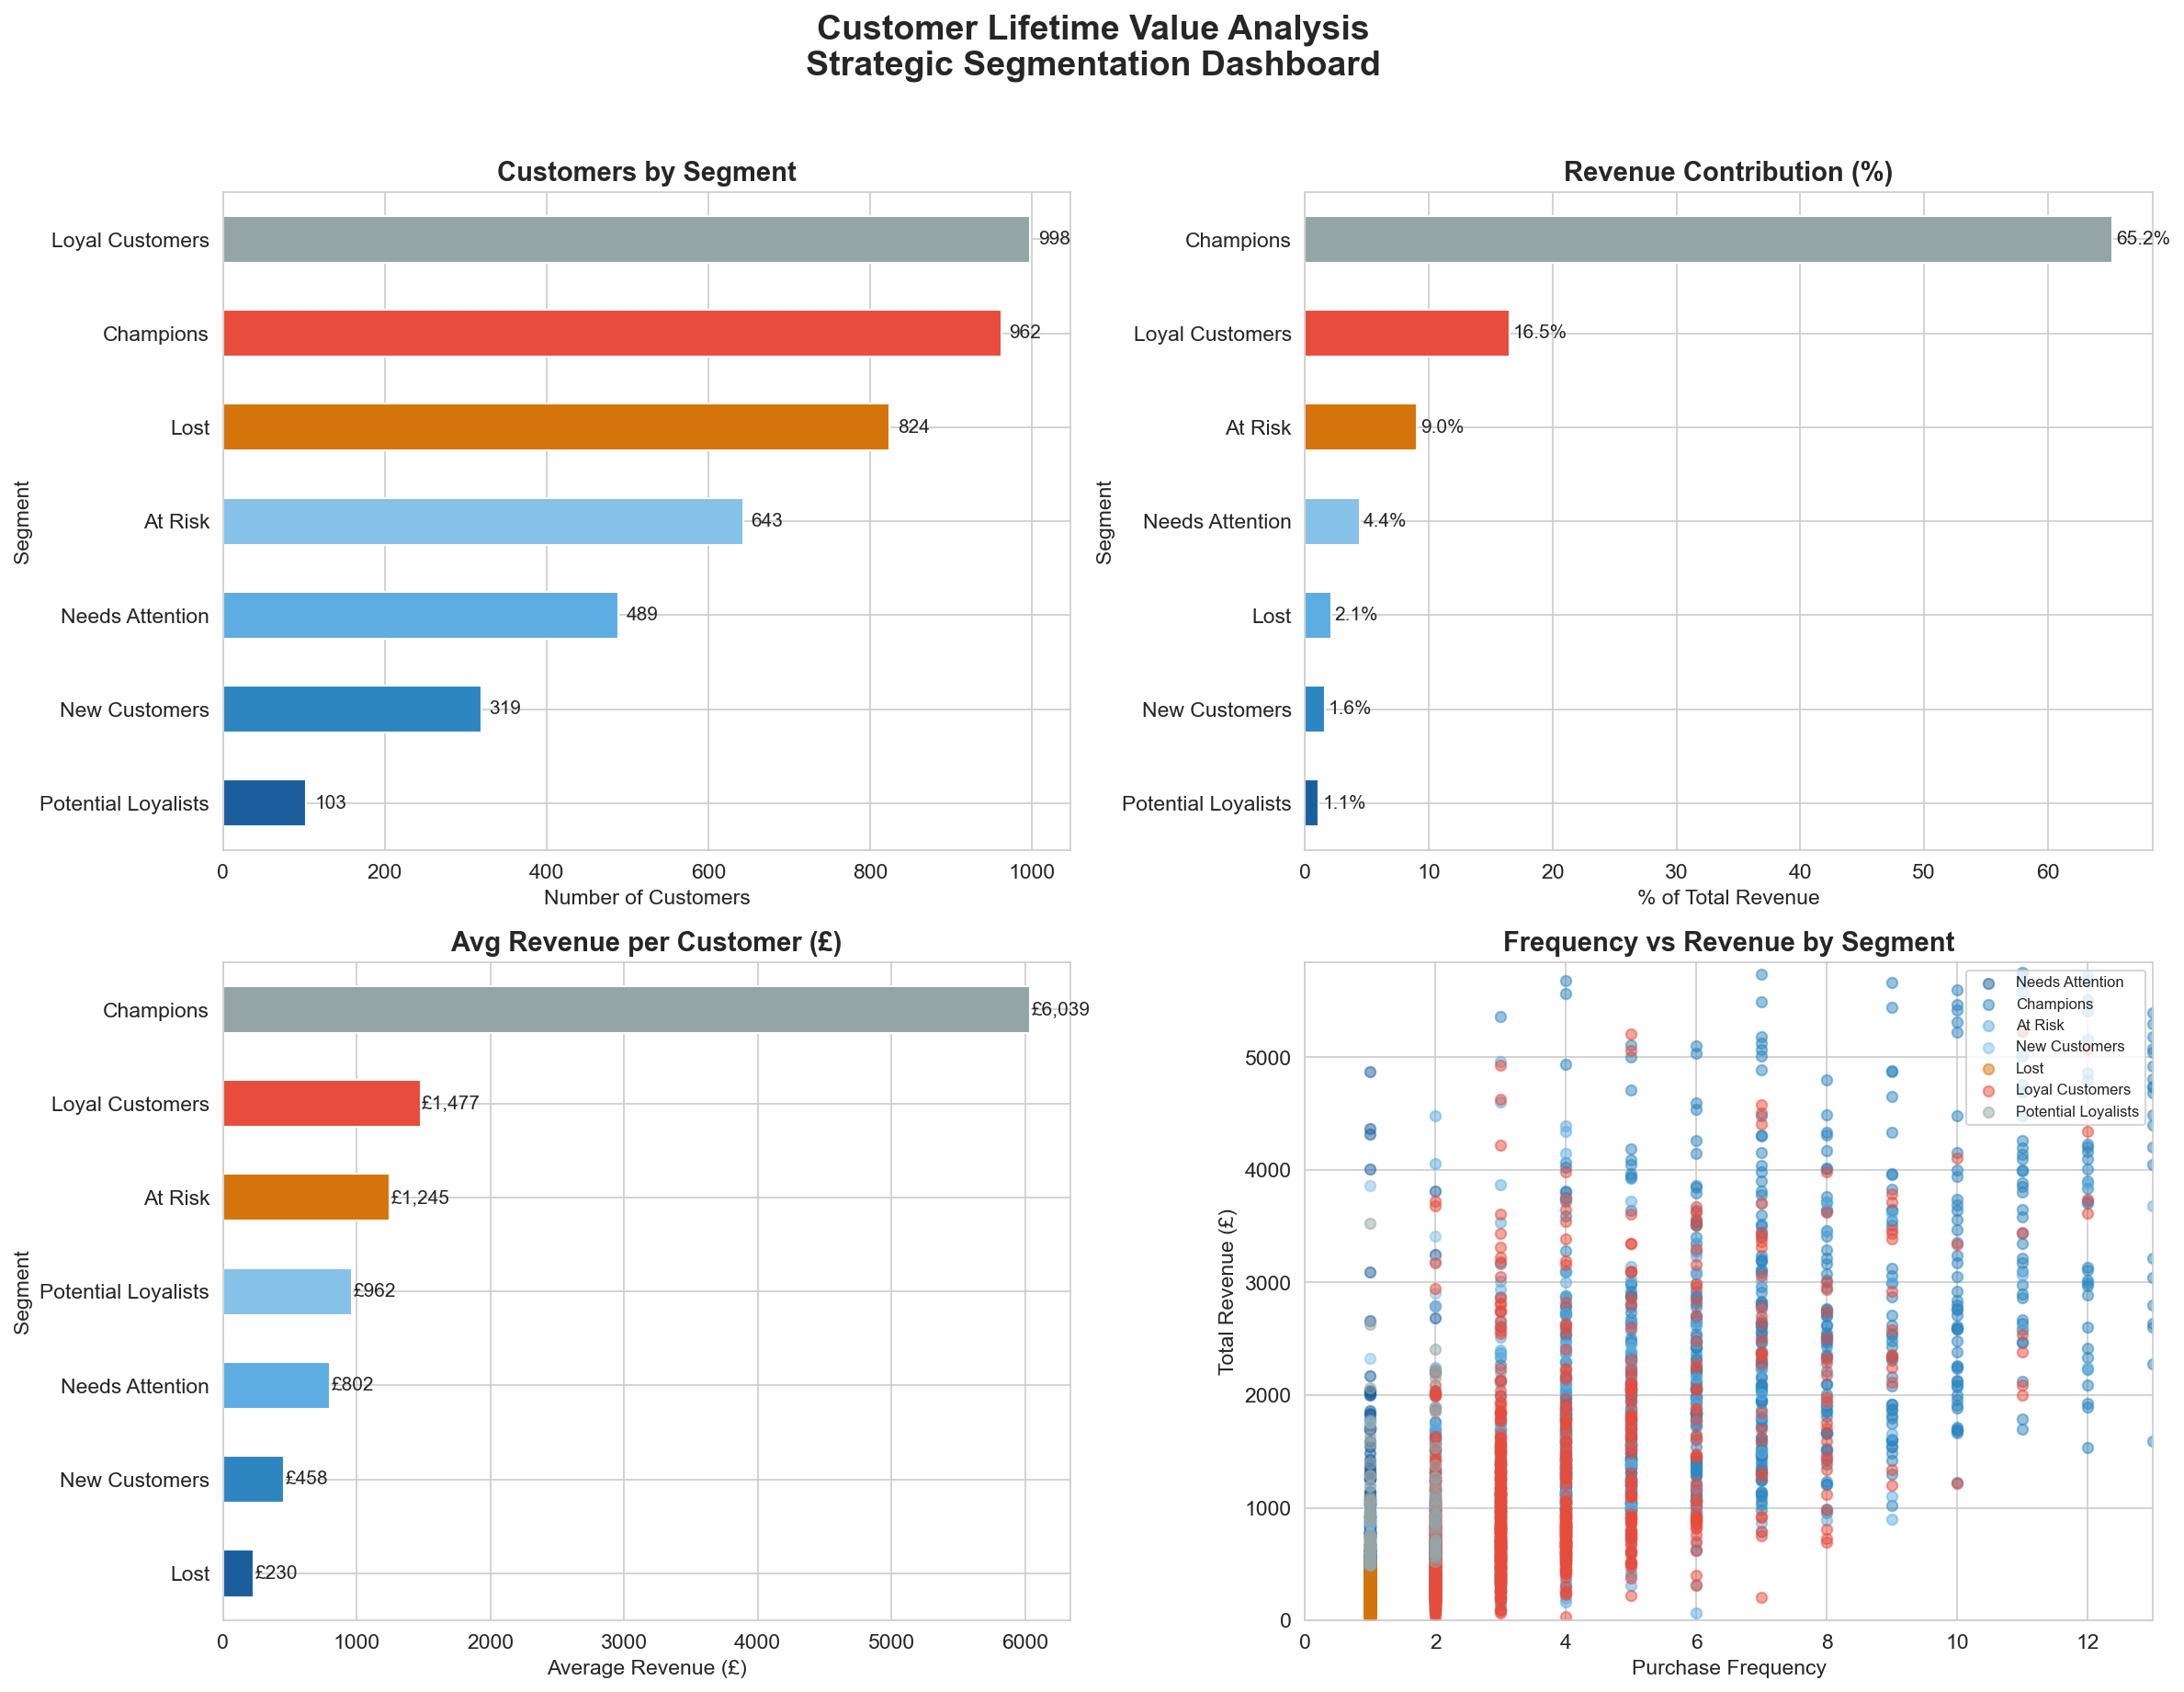


 Chart saved as 'rfm_segments.png' — use this for LinkedIn!


In [63]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Lifetime Value Analysis\nStrategic Segmentation Dashboard',
             fontsize=18, fontweight='bold', y=1.02)
 
# Define a professional colour palette
colors = ['#1B5E9E', '#2E86C1', '#5DADE2', '#85C1E9',
          '#D4740A', '#E74C3C', '#95A5A6', '#BDC3C7']
 
# --- Chart 1: Customer count by segment ---
seg_data = rfm['Segment'].value_counts().sort_values()
seg_data.plot(kind='barh', ax=axes[0, 0], color=colors[:len(seg_data)], edgecolor='white')
axes[0, 0].set_title('Customers by Segment', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Number of Customers')
for i, v in enumerate(seg_data.values):
    axes[0, 0].text(v + 10, i, str(v), va='center', fontsize=10)
 
# --- Chart 2: Revenue share by segment ---
rev_data = segment_summary['Revenue_%'].sort_values()
rev_data.plot(kind='barh', ax=axes[0, 1], color=colors[:len(rev_data)], edgecolor='white')
axes[0, 1].set_title('Revenue Contribution (%)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('% of Total Revenue')
for i, v in enumerate(rev_data.values):
    axes[0, 1].text(v + 0.3, i, f'{v}%', va='center', fontsize=10)
 
# --- Chart 3: Avg Revenue per Customer by Segment ---
avg_rev = segment_summary['Avg_Revenue_Per_Customer'].sort_values()
avg_rev.plot(kind='barh', ax=axes[1, 0], color=colors[:len(avg_rev)], edgecolor='white')
axes[1, 0].set_title('Avg Revenue per Customer (£)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Average Revenue (£)')
for i, v in enumerate(avg_rev.values):
    axes[1, 0].text(v + 10, i, f'£{v:,.0f}', va='center', fontsize=10)
 
# --- Chart 4: Recency vs Frequency scatter ---
scatter_segments = rfm['Segment'].unique()
for i, seg in enumerate(scatter_segments):
    mask = rfm['Segment'] == seg
    axes[1, 1].scatter(
        rfm[mask]['Frequency'], rfm[mask]['Monetary'],
        label=seg, alpha=0.5, s=30, color=colors[i % len(colors)]
    )
axes[1, 1].set_title('Frequency vs Revenue by Segment', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Purchase Frequency')
axes[1, 1].set_ylabel('Total Revenue (£)')
axes[1, 1].legend(fontsize=8, loc='upper right')
axes[1, 1].set_xlim(0, rfm['Frequency'].quantile(0.95))  # Remove extreme outliers from view
axes[1, 1].set_ylim(0, rfm['Monetary'].quantile(0.95))
 
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
 
print("\n Chart saved as 'rfm_segments.png' — use this for LinkedIn!")

In [64]:
print("PREDICTING CUSTOMER LIFETIME VALUE\n")
 
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import BetaGeoFitter, GammaGammaFitter
 
# Prepare data in the format the model needs
# This creates: frequency, recency, T (customer age), monetary_value
clv_data = summary_data_from_transaction_data(
    df,
    customer_id_col='CustomerID',
    datetime_col='InvoiceDate',
    monetary_value_col='Revenue',
    freq='D'  # Daily granularity
)
 
# Filter: model needs customers with at least 2 purchases
# WHY: You can't measure "repeat" behaviour from a single purchase
clv_data = clv_data[clv_data['frequency'] > 0]
print(f"Customers for CLV model: {len(clv_data):,}")
print(f"(Excluded {rfm.shape[0] - len(clv_data):,} one-time buyers)")

PREDICTING CUSTOMER LIFETIME VALUE

Customers for CLV model: 2,790
(Excluded 1,548 one-time buyers)


In [65]:
# Train the model
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(clv_data['frequency'], clv_data['recency'], clv_data['T'])
 
print(" BG/NBD Model Results\n")
 
# Predict purchases for next 30, 90, and 180 days
for days in [30, 90, 180]:
    col_name = f'predicted_purchases_{days}d'
    clv_data[col_name] = bgf.conditional_expected_number_of_purchases_up_to_time(
        days,
        clv_data['frequency'],
        clv_data['recency'],
        clv_data['T']
    )
    avg = clv_data[col_name].mean()
    print(f"   Next {days} days — avg predicted purchases per customer: {avg:.2f}")
 
# Probability of being "alive" (still an active customer)
clv_data['prob_alive'] = bgf.conditional_probability_alive(
    clv_data['frequency'],
    clv_data['recency'],
    clv_data['T']
)
 
print(f"\n   Avg probability customer is still active: {clv_data['prob_alive'].mean():.1%}")
print(f"   Customers likely still active (>50%): {(clv_data['prob_alive'] > 0.5).sum():,}")
print(f"   Customers likely gone (<50%): {(clv_data['prob_alive'] <= 0.5).sum():,}")
 

 BG/NBD Model Results

   Next 30 days — avg predicted purchases per customer: 0.50
   Next 90 days — avg predicted purchases per customer: 1.51
   Next 180 days — avg predicted purchases per customer: 3.01

   Avg probability customer is still active: 94.6%
   Customers likely still active (>50%): 2,754
   Customers likely gone (<50%): 36


In [66]:
print(" PREDICTING CUSTOMER VALUE\n")
 
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(clv_data['frequency'], clv_data['monetary_value'])
 
# Predicted CLV for the next 6 months
clv_data['predicted_clv_6m'] = ggf.customer_lifetime_value(
    bgf,
    clv_data['frequency'],
    clv_data['recency'],
    clv_data['T'],
    clv_data['monetary_value'],
    time=6,              # 6 months
    freq='D',            # Daily frequency
    discount_rate=0.01   # Monthly discount rate
)
 
print(f"--- Predicted 6-Month CLV Distribution ---")
print(f"   Min:    £{clv_data['predicted_clv_6m'].min():.2f}")
print(f"   Median: £{clv_data['predicted_clv_6m'].median():.2f}")
print(f"   Mean:   £{clv_data['predicted_clv_6m'].mean():.2f}")
print(f"   Max:    £{clv_data['predicted_clv_6m'].max():.2f}")
print(f"   Total:  £{clv_data['predicted_clv_6m'].sum():,.2f}")
 
print(f"\n Top 10 Most Valuable Customers (Next 6 Months):")
top_10 = clv_data.nlargest(10, 'predicted_clv_6m')[
    ['frequency', 'monetary_value', 'prob_alive', 'predicted_clv_6m']
].round(2)
print(top_10.to_string())
 
 

 PREDICTING CUSTOMER VALUE

--- Predicted 6-Month CLV Distribution ---
   Min:    £6.58
   Median: £783.99
   Mean:   £1597.07
   Max:    £298185.80
   Total:  £4,455,820.85

 Top 10 Most Valuable Customers (Next 6 Months):
            frequency  monetary_value  prob_alive  predicted_clv_6m
CustomerID                                                         
16446             1.0       168469.60        0.95         298185.80
14646            44.0         6366.71        1.00         114016.87
18102            25.0         9349.48        1.00          95174.16
17450            26.0         7404.69        1.00          78177.78
14096            16.0         4071.43        1.00          65783.56
14911           131.0         1093.66        1.00          54478.67
12415            15.0         7860.21        1.00          53642.61
14156            42.0         2787.08        1.00          45964.54
17511            27.0         3305.06        1.00          35687.29
16029            38.0       

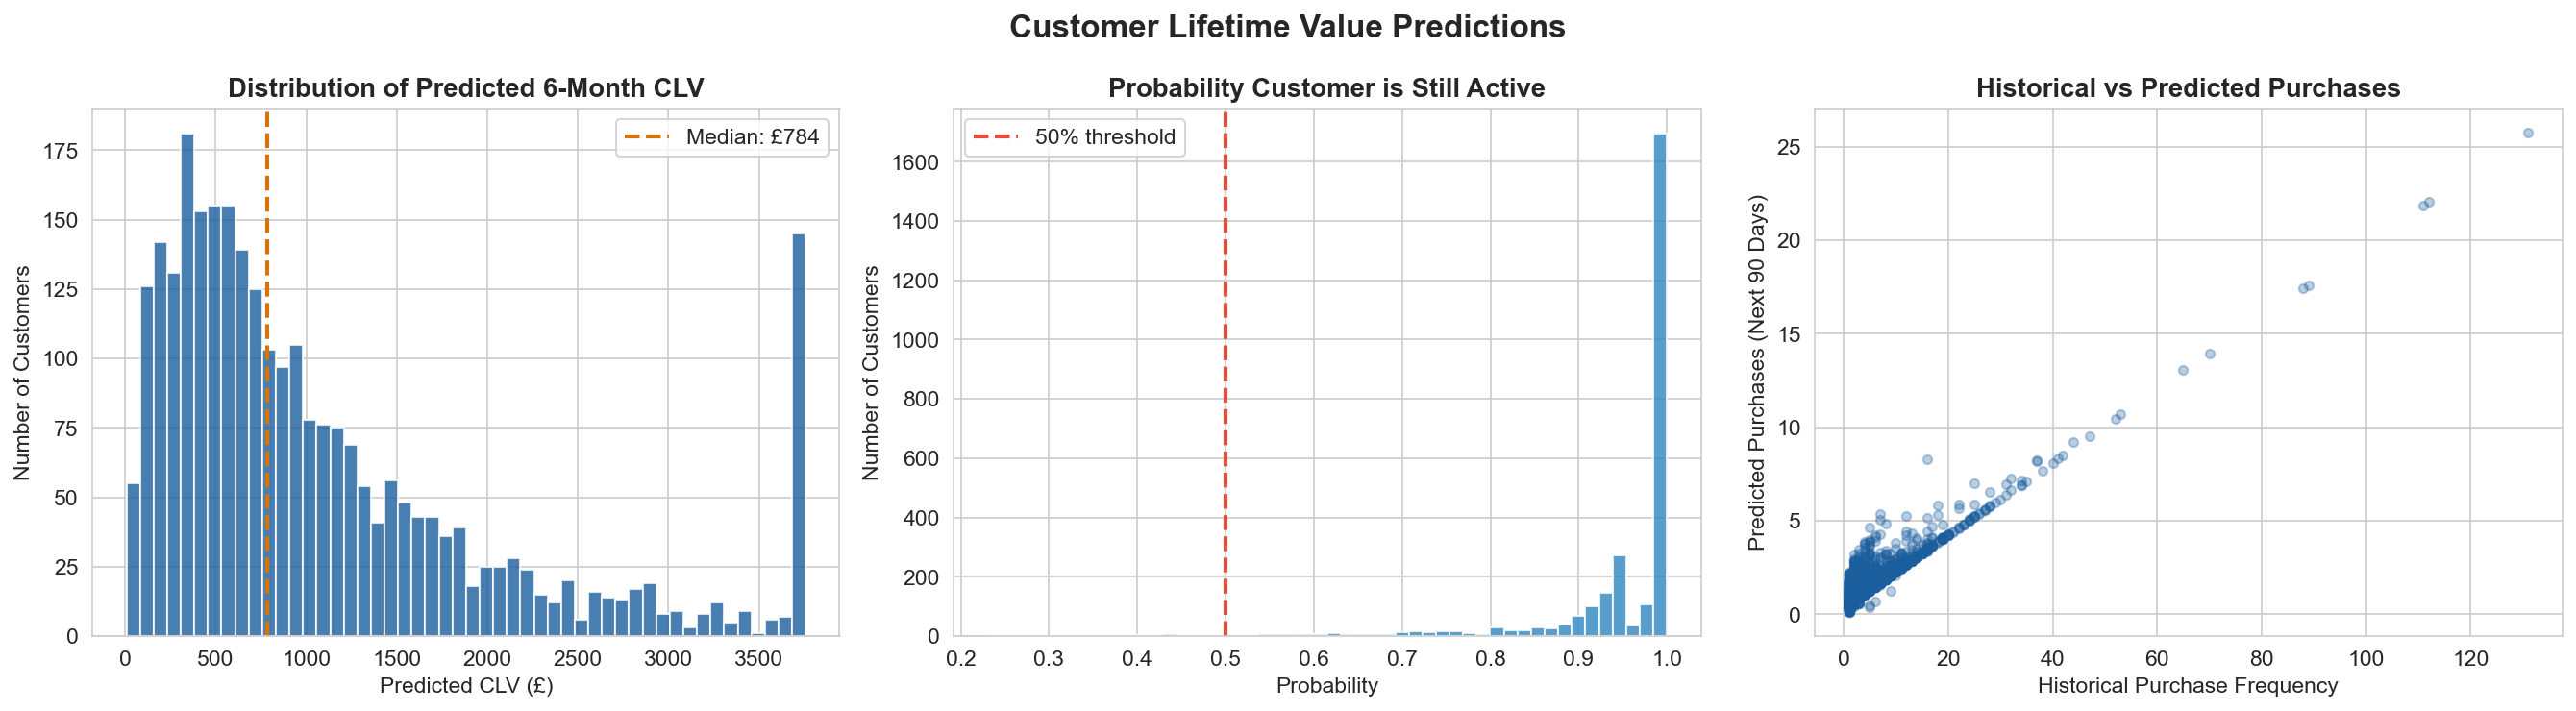


 Chart saved as 'clv_predictions.png'


In [67]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Lifetime Value Predictions', fontsize=16, fontweight='bold')
 
# Chart 1: CLV Distribution
axes[0].hist(clv_data['predicted_clv_6m'].clip(upper=clv_data['predicted_clv_6m'].quantile(0.95)),
             bins=50, color='#1B5E9E', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Predicted 6-Month CLV', fontweight='bold')
axes[0].set_xlabel('Predicted CLV (£)')
axes[0].set_ylabel('Number of Customers')
axes[0].axvline(clv_data['predicted_clv_6m'].median(), color='#D4740A',
                linestyle='--', linewidth=2, label=f"Median: £{clv_data['predicted_clv_6m'].median():.0f}")
axes[0].legend()
 
# Chart 2: Probability of Being Alive
axes[1].hist(clv_data['prob_alive'], bins=50, color='#2E86C1', edgecolor='white', alpha=0.8)
axes[1].set_title('Probability Customer is Still Active', fontweight='bold')
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('Number of Customers')
axes[1].axvline(0.5, color='#E74C3C', linestyle='--', linewidth=2, label='50% threshold')
axes[1].legend()
 
# Chart 3: Actual vs Expected Frequency
axes[2].scatter(clv_data['frequency'], clv_data['predicted_purchases_90d'],
                alpha=0.3, s=20, color='#1B5E9E')
axes[2].set_title('Historical vs Predicted Purchases', fontweight='bold')
axes[2].set_xlabel('Historical Purchase Frequency')
axes[2].set_ylabel('Predicted Purchases (Next 90 Days)')
 
plt.tight_layout()
plt.savefig('clv_predictions.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
 
print("\n Chart saved as 'clv_predictions.png'")

In [68]:
print(" MERGING RFM SEGMENTS WITH CLV PREDICTIONS\n")
 
final = rfm.merge(
    clv_data[['predicted_clv_6m', 'predicted_purchases_90d', 'prob_alive']],
    left_on='CustomerID',
    right_index=True,
    how='left'
)
 
# Segment-level CLV summary — THIS IS YOUR STRATEGY TABLE
strategy = final.groupby('Segment').agg({
    'CustomerID': 'count',
    'Monetary': 'sum',
    'predicted_clv_6m': ['mean', 'sum'],
    'prob_alive': 'mean'
}).round(1)
 
strategy.columns = ['Customers', 'Historical_Revenue', 'Avg_CLV_6M',
                     'Total_Predicted_CLV_6M', 'Avg_Prob_Alive']
 
strategy['Revenue_%'] = (strategy['Historical_Revenue'] /
                         strategy['Historical_Revenue'].sum() * 100).round(1)
 
strategy = strategy.sort_values('Total_Predicted_CLV_6M', ascending=False)
print(strategy.to_string())

 MERGING RFM SEGMENTS WITH CLV PREDICTIONS

                     Customers  Historical_Revenue  Avg_CLV_6M  Total_Predicted_CLV_6M  Avg_Prob_Alive  Revenue_%
Segment                                                                                                          
Champions                  962           5809341.1      2787.5               2678747.5             1.0       65.2
Loyal Customers            998           1474127.6      1230.2               1201869.4             1.0       16.5
At Risk                    643            800531.6       638.3                395088.8             0.9        9.0
New Customers              319            146166.6      1082.6                 82281.1             0.9        1.6
Needs Attention            489            392341.6       579.8                 48121.4             0.8        4.4
Potential Loyalists        103             99128.7      1104.9                 44195.8             0.9        1.1
Lost                       824            18

In [69]:
print("=" * 60)
print(" STRATEGIC RECOMMENDATIONS")
print("=" * 60)
 
for segment in strategy.index:
    row = strategy.loc[segment]
    customers = int(row['Customers'])
    rev_pct = row['Revenue_%']
    avg_clv = row['Avg_CLV_6M']
    prob_alive = row['Avg_Prob_Alive']
 
    print(f"\n{'─' * 50}")
    print(f"SEGMENT: {segment}")
    print(f"   Customers: {customers} | Revenue share: {rev_pct}%")
    print(f"   Avg predicted 6M value: £{avg_clv:,.2f}")
    print(f"   Avg probability still active: {prob_alive:.0%}")
 
    # Strategic recommendation based on segment characteristics
    clean_seg = segment.split(' ', 1)[-1] if ' ' in segment else segment
    if 'Champion' in clean_seg:
        print(f"   STRATEGY: PROTECT & REWARD")
        print(f"   → VIP loyalty program with exclusive early access")
        print(f"   → Personalised thank-you communications")
        print(f"   → These customers fund your business. Losing even one is costly.")
    elif 'Loyal' in clean_seg:
        print(f"   STRATEGY: UPSELL & DEEPEN")
        print(f"   → Cross-sell related products")
        print(f"   → Referral program (loyal customers bring loyal customers)")
        print(f"   → Invest moderately — they're stable but can grow.")
    elif 'New' in clean_seg:
        print(f"   STRATEGY: NURTURE CAREFULLY")
        print(f"   → Welcome email series with personalised recommendations")
        print(f"   → Early repeat-purchase incentive (10% off second order)")
        print(f"   → Goal: convert them into Loyal Customers within 90 days.")
    elif 'Potential' in clean_seg:
        print(f"   STRATEGY: ENCOURAGE GROWTH")
        print(f"   → Targeted offers based on purchase history")
        print(f"   → Engagement campaigns (surveys, feedback requests)")
        print(f"   → High potential — worth the investment.")
    elif 'At Risk' in clean_seg:
        print(f"   STRATEGY: URGENT WIN-BACK")
        print(f"   → Immediate reactivation campaign (limited-time offer)")
        print(f"   → Personal outreach: 'We miss you' email with incentive")
        print(f"   → Every week of delay reduces recovery probability.")
    elif "Can't Lose" in clean_seg or 'Lose' in clean_seg:
        print(f"   STRATEGY: HIGHEST PRIORITY WIN-BACK")
        print(f"   → Personal phone call or handwritten note from account manager")
        print(f"   → Understand WHY they left (survey or direct conversation)")
        print(f"   → These are your most valuable defectors. Act THIS WEEK.")
    elif 'Lost' in clean_seg:
        print(f"   STRATEGY: STOP SPENDING")
        print(f"   → Remove from active marketing lists")
        print(f"   → Reallocate this budget to Champions and At-Risk segments")
        print(f"   → Investing here has near-zero ROI.")
    elif 'Attention' in clean_seg:
        print(f"   STRATEGY: MONITOR & TEST")
        print(f"   → A/B test different offers to find what moves them")
        print(f"   → Low-cost engagement (email, social) — don't overspend")
        print(f"   → Some will graduate up; others will fade. Test to find out.")
 

 STRATEGIC RECOMMENDATIONS

──────────────────────────────────────────────────
SEGMENT: Champions
   Customers: 962 | Revenue share: 65.2%
   Avg predicted 6M value: £2,787.50
   Avg probability still active: 100%
   STRATEGY: PROTECT & REWARD
   → VIP loyalty program with exclusive early access
   → Personalised thank-you communications
   → These customers fund your business. Losing even one is costly.

──────────────────────────────────────────────────
SEGMENT: Loyal Customers
   Customers: 998 | Revenue share: 16.5%
   Avg predicted 6M value: £1,230.20
   Avg probability still active: 100%

──────────────────────────────────────────────────
SEGMENT: At Risk
   Customers: 643 | Revenue share: 9.0%
   Avg predicted 6M value: £638.30
   Avg probability still active: 90%

──────────────────────────────────────────────────
SEGMENT: New Customers
   Customers: 319 | Revenue share: 1.6%
   Avg predicted 6M value: £1,082.60
   Avg probability still active: 90%

────────────────────────────